In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import Models and Accuracy_metrics
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_score,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve)

In [3]:
#extras like save model and warnings etc
import warnings
import pickle as pk

from sklearn.pipeline import Pipeline
 
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

In [4]:
df = pd.read_csv('loan_approval_dataset.csv')

In [5]:
df.shape

(4269, 13)

In [6]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [8]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [9]:
# Stripping whitespace from columns names and string values
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [10]:
# Drop loan_id — Unique for everyone , won't make much sense either
df.drop(columns=['loan_id'], inplace=True)

In [12]:
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}\n")

Rows: 4269   Columns: 12



In [13]:
print(df.dtypes)

no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object


In [14]:
counts = df['loan_status'].value_counts()
pct    = df['loan_status'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'Count': counts, 'Percent (%)': pct}))

          Count  Percent (%)
Approved   2656         62.2
Rejected   1613         37.8


In [18]:
# 62% Approved, 38% Rejected — mild imbalance.
# We empirically verified: class_weight='balanced' and manual reweighting
# gave identical ROC-AUC (0.9934) but traded FN for FP vs baseline.
# Minority class (Rejected) F1 = 0.977 without any intervention — no collapse.
# Conclusion: imbalance handling not needed HERE, but always verify with metrics,
# not by rule of thumb. The right answer depends on business cost of FP vs FN.

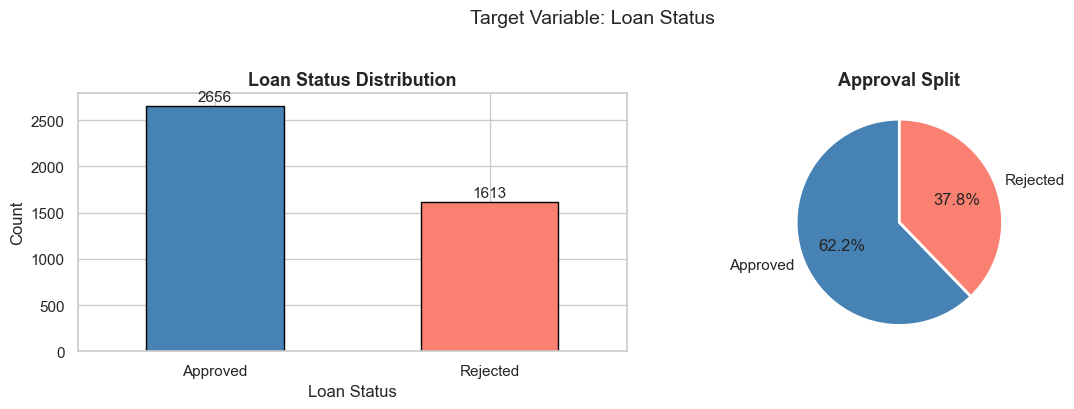

In [19]:
#EDA - Exploratory Data Analysis starts here , using different techniques to know about data

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Loan Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Approved', 'Rejected'], rotation=0)
for bar, val in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 str(val), ha='center', va='bottom', fontsize=11)
 
axes[1].pie(counts, labels=['Approved', 'Rejected'], autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Approval Split', fontsize=13, fontweight='bold')
 
plt.suptitle('Target Variable: Loan Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

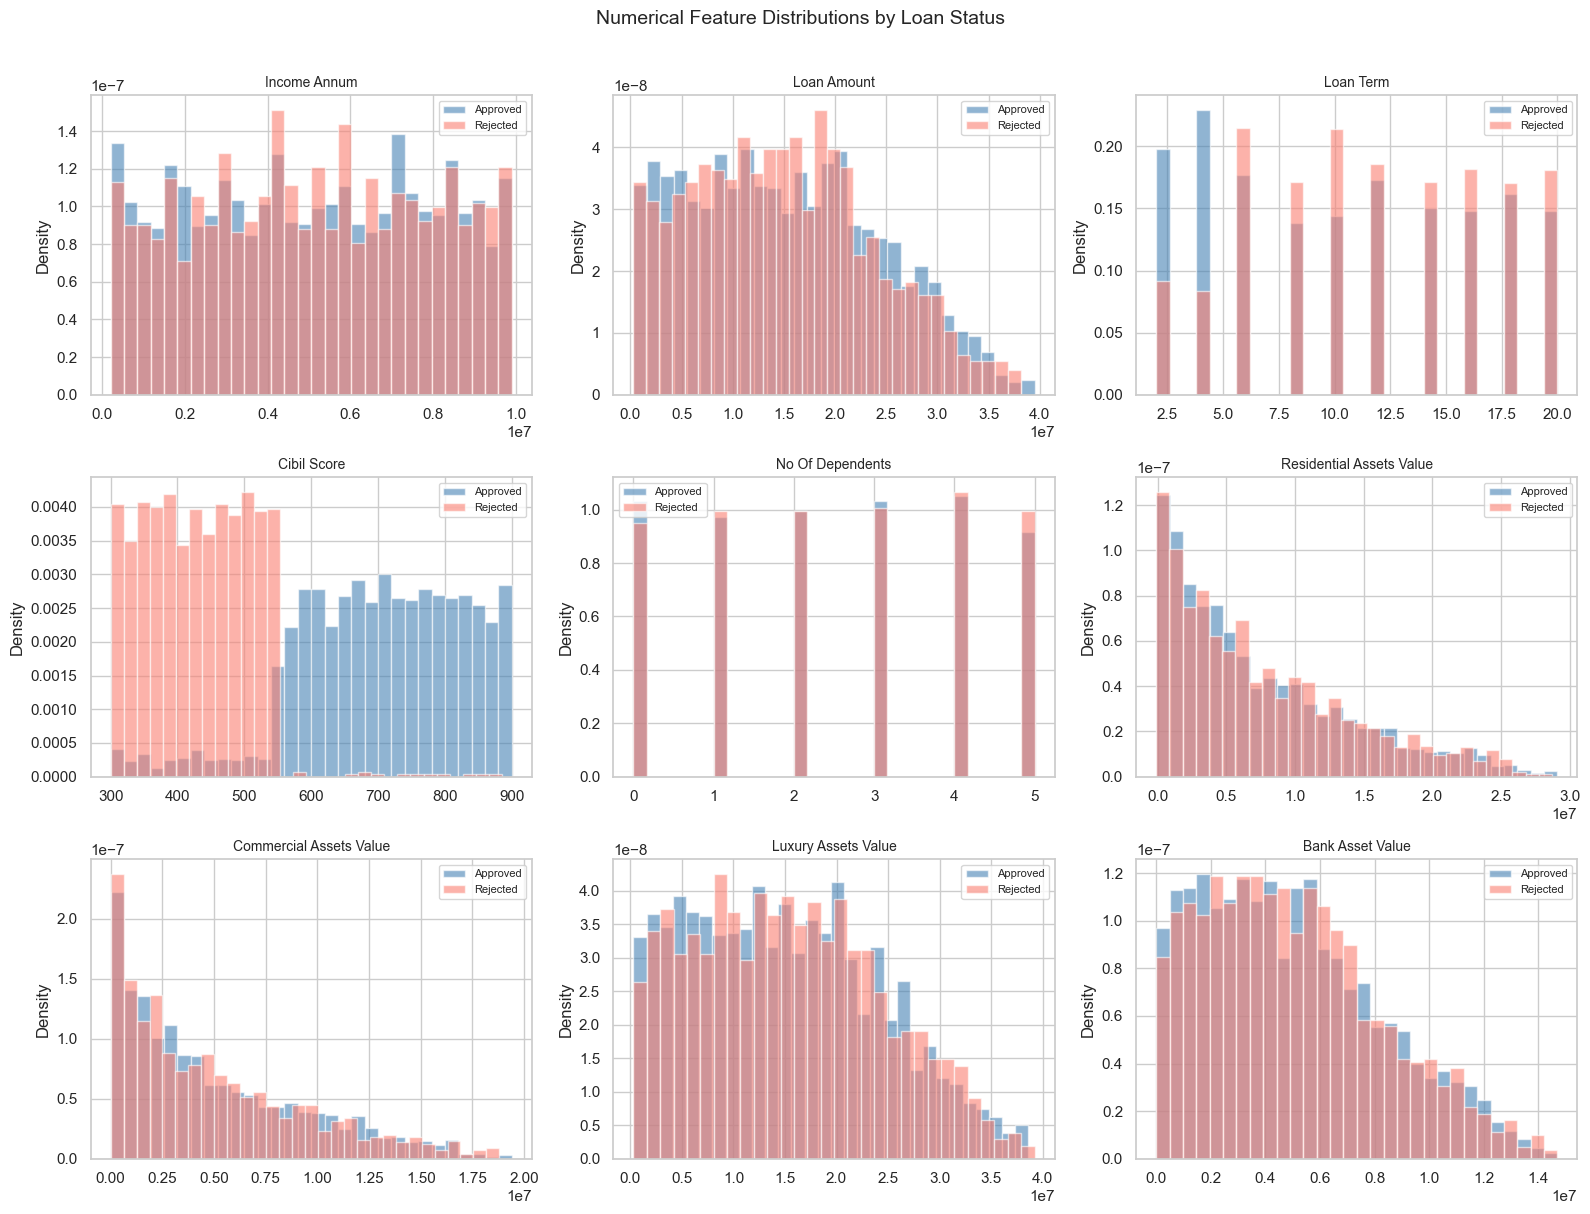

In [20]:
num_cols = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score',
            'no_of_dependents', 'residential_assets_value',
            'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
 
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[df['loan_status'] == 'Approved'][col],  bins=30, alpha=0.6,
            label='Approved', color='steelblue', density=True)
    ax.hist(df[df['loan_status'] == 'Rejected'][col],  bins=30, alpha=0.6,
            label='Rejected', color='salmon', density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')
 
plt.suptitle('Numerical Feature Distributions by Loan Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# income_annum and loan_amount are roughly uniform (dataset is synthetic/cleaned).
# cibil_score shows clear bimodal separation — approved loans cluster above 700,
# rejected ones cluster below. This is the strongest individual predictor.

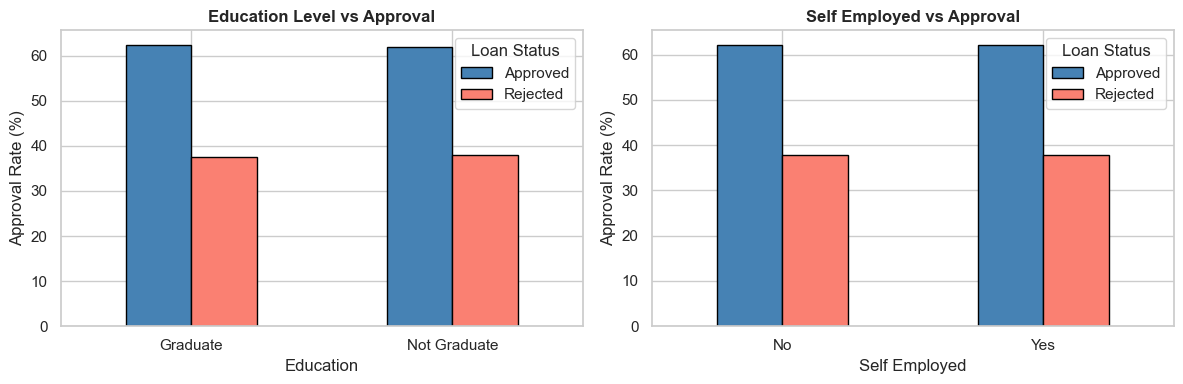

Statistical Summary
                           count         mean         std       min  \
no_of_dependents          4269.0         2.50        1.70       0.0   
income_annum              4269.0   5059123.92  2806839.83  200000.0   
loan_amount               4269.0  15133450.46  9043362.98  300000.0   
loan_term                 4269.0        10.90        5.71       2.0   
cibil_score               4269.0       599.94      172.43     300.0   
residential_assets_value  4269.0   7472616.54  6503636.59 -100000.0   
commercial_assets_value   4269.0   4973155.31  4388966.09       0.0   
luxury_assets_value       4269.0  15126305.93  9103753.67  300000.0   
bank_asset_value          4269.0   4976692.43  3250185.31       0.0   

                                25%         50%         75%         max  
no_of_dependents                1.0         3.0         4.0         5.0  
income_annum              2700000.0   5100000.0   7500000.0   9900000.0  
loan_amount               7700000.0  14500000.0

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
for ax, col, title in zip(axes,
                           ['education', 'self_employed'],
                           ['Education Level vs Approval', 'Self Employed vs Approval']):
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Approval Rate (%)')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Loan Status')
 
plt.tight_layout()
plt.show()
 
print("Statistical Summary")
print(df.describe().round(2).T)

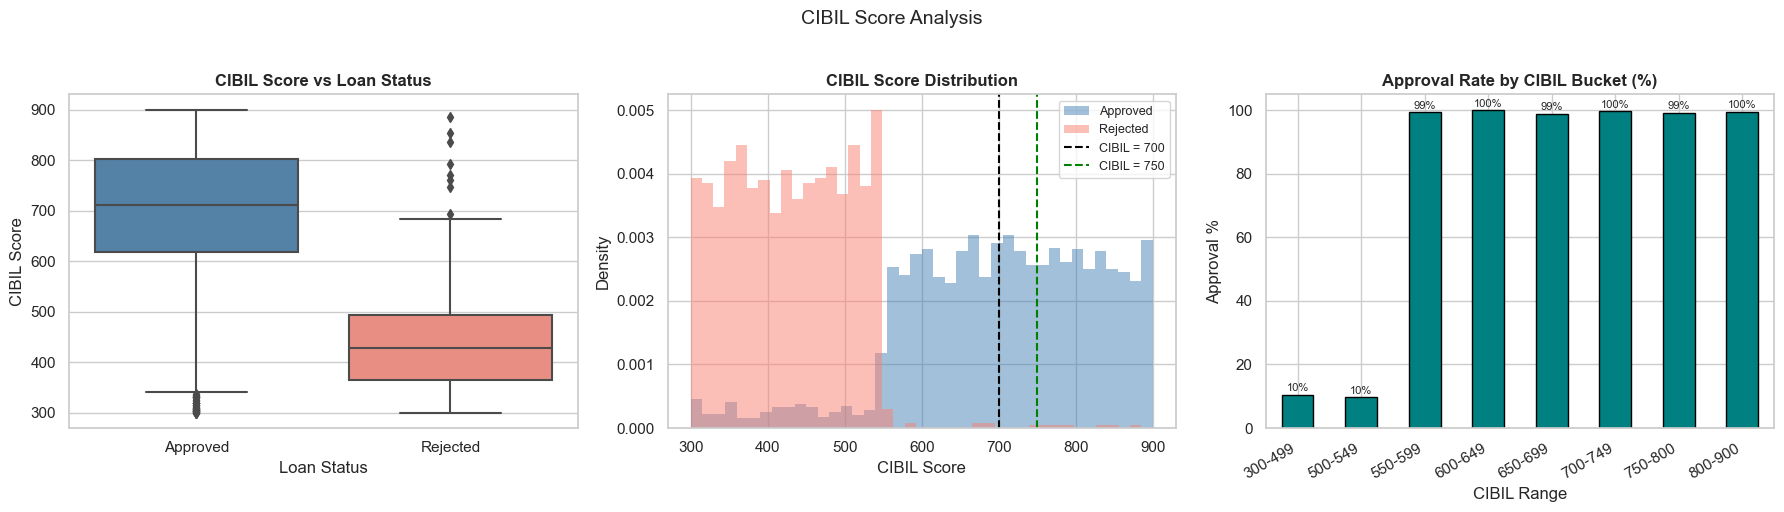

CIBIL Score Statistics by Loan Status
              count    mean     std    min    25%    50%    75%    max
loan_status                                                           
Approved     2656.0  703.46  125.25  300.0  618.0  711.0  803.0  900.0
Rejected     1613.0  429.47   78.40  300.0  364.0  429.0  493.0  885.0


In [28]:
#Knowing about Cibil Score as seen in Numerical Feature Distributions by Loan Status

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Box plot
sns.boxplot(x='loan_status', y='cibil_score', data=df,
            palette={'Approved': 'steelblue', 'Rejected': 'salmon'}, ax=axes[0])
axes[0].set_title('CIBIL Score vs Loan Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('CIBIL Score')
 
# KDE plot
for status, color in [('Approved', 'steelblue'), ('Rejected', 'salmon')]:
    subset = df[df['loan_status'] == status]['cibil_score']
    axes[1].hist(subset, bins=40, alpha=0.5, label=status, color=color,
                 density=True, edgecolor='none')
axes[1].axvline(700, color='black', linestyle='--', linewidth=1.5, label='CIBIL = 700')
axes[1].axvline(750, color='green', linestyle='--', linewidth=1.5, label='CIBIL = 750')
axes[1].set_title('CIBIL Score Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlabel('CIBIL Score')
axes[1].set_ylabel('Density')
#Approval rate by Cibil bucket 

df_temp = df.copy()
df_temp['cibil_bucket'] = pd.cut(df_temp['cibil_score'],
                                  bins=[300, 499, 549, 599, 649, 699, 749, 800, 900],
                                  labels=['300-499','500-549','550-599','600-649',
                                          '650-699','700-749','750-800','800-900'])
rate = df_temp.groupby('cibil_bucket', observed=True)['loan_status'].apply(
    lambda x: (x == 'Approved').mean() * 100
)
rate.plot(kind='bar', ax=axes[2], color='teal', edgecolor='black')
axes[2].set_title('Approval Rate by CIBIL Bucket (%)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Approval %')
axes[2].set_xlabel('CIBIL Range')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
for bar, val in zip(axes[2].patches, rate):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
 
plt.suptitle('CIBIL Score Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
 
print("CIBIL Score Statistics by Loan Status")
print(df.groupby('loan_status')['cibil_score'].describe().round(2))

In [29]:
# The approval rate jumps from ~0% below 500 to ~100% above 750.
# This non-linear step behaviour is exactly why we create threshold flags
# and bins later — Logistic Regression is linear and can't discover this on its own.

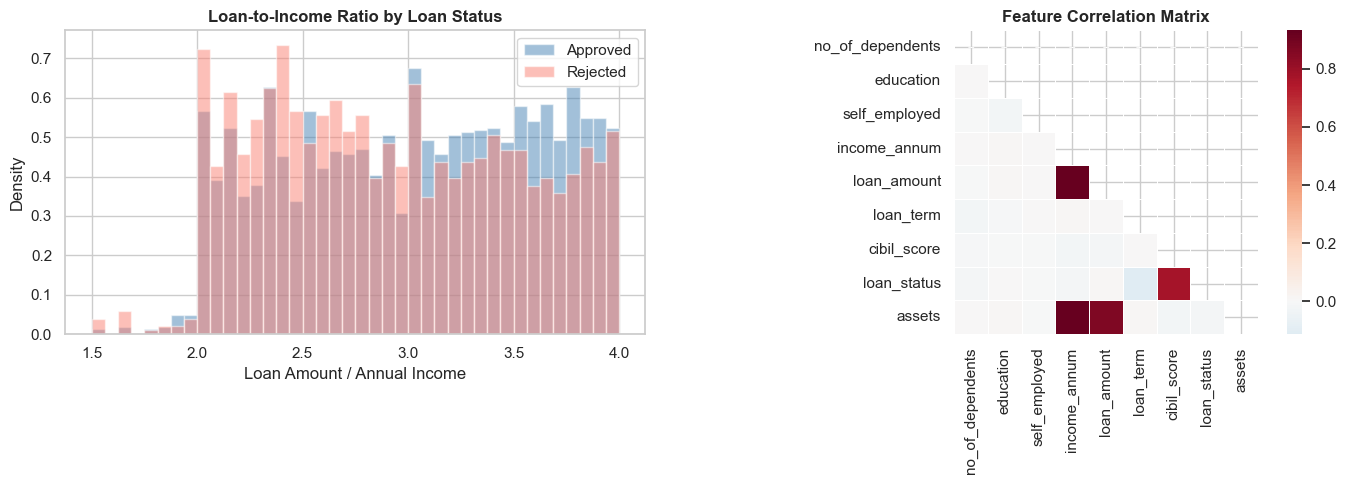

Correlation with Loan Status (ranked)
cibil_score         0.771
loan_amount         0.016
education           0.005
self_employed       0.000
assets             -0.011
income_annum       -0.015
no_of_dependents   -0.018
loan_term          -0.113
Name: loan_status, dtype: float64


In [31]:
df_temp2 = df.copy()
df_temp2['lti_ratio'] = df_temp2['loan_amount'] / df_temp2['income_annum']
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for status, color in [('Approved', 'steelblue'), ('Rejected', 'salmon')]:
    subset = df_temp2[df_temp2['loan_status'] == status]['lti_ratio']
    axes[0].hist(subset, bins=40, alpha=0.5, label=status, color=color, density=True)
axes[0].set_title('Loan-to-Income Ratio by Loan Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loan Amount / Annual Income')
axes[0].set_ylabel('Density')
axes[0].legend()

df_corr = df.copy()
df_corr['education']   = df_corr['education'].map({'Graduate': 1, 'Not Graduate': 0})
df_corr['self_employed'] = df_corr['self_employed'].map({'Yes': 1, 'No': 0})
df_corr['loan_status'] = df_corr['loan_status'].map({'Approved': 1, 'Rejected': 0})
df_corr['assets'] = (df_corr['residential_assets_value'] + df_corr['commercial_assets_value'] +
                     df_corr['luxury_assets_value'] + df_corr['bank_asset_value'])
df_corr.drop(columns=['residential_assets_value','commercial_assets_value',
                       'luxury_assets_value','bank_asset_value'], inplace=True)
 
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 8})
axes[1].set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
 
print("Correlation with Loan Status (ranked)")
print(corr['loan_status'].drop('loan_status').sort_values(ascending=False).round(3))

In [32]:
# cibil_score has the highest correlation with loan_status (check output above).
# income_annum and loan_amount have low direct correlation — but their RATIO
# is informative, which is why we engineer it as a feature.

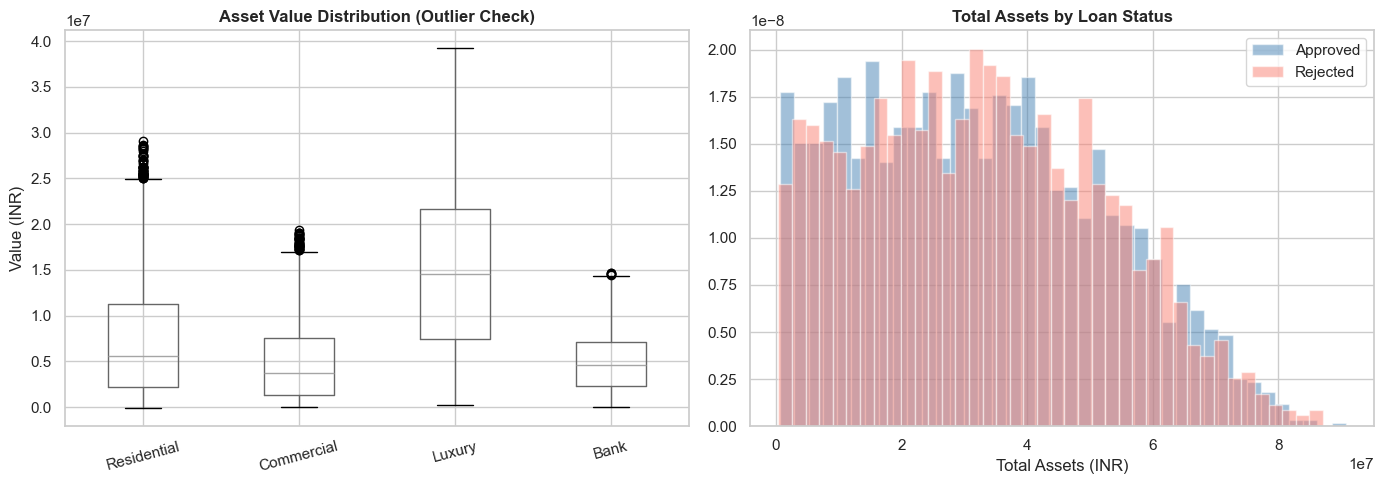

Negative Asset Values (Data Quality Check)
  residential_assets_value: 28 negative values
  commercial_assets_value:  No negatives
  luxury_assets_value:  No negatives
  bank_asset_value:  No negatives


In [58]:
asset_cols = ['residential_assets_value', 'commercial_assets_value',
              'luxury_assets_value', 'bank_asset_value']
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Box plots for all 4 asset types
df[asset_cols].boxplot(ax=axes[0], vert=True)
axes[0].set_title('Asset Value Distribution (Outlier Check)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value (INR)')
axes[0].set_xticklabels(['Residential', 'Commercial', 'Luxury', 'Bank'], rotation=15)
 
# Total assets by approval
df_temp3 = df.copy()
df_temp3['total_assets'] = df_temp3[asset_cols].sum(axis=1)
for status, color in [('Approved', 'steelblue'), ('Rejected', 'salmon')]:
    subset = df_temp3[df_temp3['loan_status'] == status]['total_assets']
    axes[1].hist(subset, bins=40, alpha=0.5, label=status, color=color, density=True)
axes[1].set_title('Total Assets by Loan Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Assets (INR)')
axes[1].legend()
 
plt.tight_layout()
plt.show()
 
# Check for negative asset values (data quality issue in raw data)
print("Negative Asset Values (Data Quality Check)")
for col in asset_cols:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f"  {col}: {neg} negative values")
    else:
        print(f"  {col}:  No negatives")

In [59]:
df_model = df.copy()
 
# Binary encode categorical columns
# Graduate=1 (better credit profile), Not Graduate=0
df_model['education']    = df_model['education'].map({'Graduate': 1, 'Not Graduate': 0})
df_model['self_employed']= df_model['self_employed'].map({'Yes': 1, 'No': 0})
df_model['loan_status']  = df_model['loan_status'].map({'Approved': 1, 'Rejected': 0})
 
# Aggregate 4 asset columns into one total_assets feature.

df_model['assets'] = (df_model['residential_assets_value'] +
                      df_model['commercial_assets_value']  +
                      df_model['luxury_assets_value']      +
                      df_model['bank_asset_value'])
 
df_model.drop(columns=['residential_assets_value', 'commercial_assets_value',
                        'luxury_assets_value', 'bank_asset_value'], inplace=True)
 
print("Encoded Dataset looks like :-")
print(df_model.head())
print(f"\nShape: {df_model.shape}")
print("\nEncoding check:")
print(f"  education unique values    : {sorted(df_model['education'].unique())}")
print(f"  self_employed unique values: {sorted(df_model['self_employed'].unique())}")
print(f"  loan_status unique values  : {sorted(df_model['loan_status'].unique())}")

Encoded Dataset looks like :-
   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          1              0       9600000     29900000   
1                 0          0              1       4100000     12200000   
2                 3          1              0       9100000     29700000   
3                 3          1              0       8200000     30700000   
4                 5          0              1       9800000     24200000   

   loan_term  cibil_score  loan_status    assets  
0         12          778            1  50700000  
1          8          417            0  17000000  
2         20          506            0  57700000  
3          8          467            0  52700000  
4         20          382            0  55000000  

Shape: (4269, 9)

Encoding check:
  education unique values    : [0, 1]
  self_employed unique values: [0, 1]
  loan_status unique values  : [0, 1]


In [60]:
# We use binary encoding (not one-hot) here because both categoricals are
# already binary-natured (Graduate/Not Graduate, Yes/No). 
# One-hot encoding would just add a redundant column.
 

In [61]:
X = df_model.drop(columns=['loan_status']).copy()
y = df_model['loan_status']


In [62]:
 
#1. CIBIL Score Ordinal Binning 
# Real banks use CIBIL score ranges as policy thresholds, not as a linear value.
# Below 500 = almost certain rejection; above 750 = near-certain approval.
# Encoding this as ordered bins gives the linear model a handle on step behaviour.
X['cibil_bin'] = pd.cut(X['cibil_score'],
                         bins=[0, 499, 549, 599, 649, 699, 724, 749, 800, 1000],
                         labels=[0, 1, 2, 3, 4, 5, 6, 7, 8]).astype(float)
 
#2. CIBIL Threshold Flags (domain knowledge)
# These capture the hard cutoff boundaries banks apply in lending policy.
X['cibil_gte_700'] = (X['cibil_score'] >= 700).astype(int)   # Good
X['cibil_gte_750'] = (X['cibil_score'] >= 750).astype(int)   # Very Good
X['cibil_lt_500']  = (X['cibil_score'] <  500).astype(int)   # Low
 
#3. Quadratic CIBIL Term 
# Allows the model to fit a curved (non-linear) response surface for CIBIL.
X['cibil_sq'] = X['cibil_score'] ** 2
 
#4. Ratio Features 
# Raw income and loan amounts don't tell the full story — context matters.
# A ₹50L loan is very different for someone earning ₹10L vs ₹2Cr/year.
X['loan_to_income'] = X['loan_amount'] / (X['income_annum'] + 1)   # repayment burden
X['loan_to_assets'] = X['loan_amount'] / (X['assets'] + 1)          # collateral coverage
X['income_per_dep'] = X['income_annum'] / (X['no_of_dependents'] + 1)  # disposable income proxy

#If any row has income_annum = 0, assets = 0, or no_of_dependents = 0, 
#dividing by it gives inf or ZeroDivisionError, which breaks StandardScaler and the model.
#Adding 1 ensures the denominator is never zero.
 
#5. Interaction Feature
X['cibil_x_income'] = X['cibil_score'] * X['income_annum']  # high CIBIL + high income = low risk

In [63]:
# 6. Log Transforms for Skewed Financial Columns

for col in ['income_annum', 'loan_amount', 'assets']:
    X[f'log_{col}'] = np.log1p(X[col])
 
print(f"Original features : 8")
print(f"After engineering : {X.shape[1]}")
print(f"\nAll features:\n{list(X.columns)}")
 
# Quick sanity check — no NaN introduced
print(f"\nNaN values in X after engineering: {X.isnull().sum().sum()}")

Original features : 8
After engineering : 20

All features:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'assets', 'cibil_bin', 'cibil_gte_700', 'cibil_gte_750', 'cibil_lt_500', 'cibil_sq', 'loan_to_income', 'loan_to_assets', 'income_per_dep', 'cibil_x_income', 'log_income_annum', 'log_loan_amount', 'log_assets']

NaN values in X after engineering: 0


In [64]:
# income_annum, loan_amount, assets are right-skewed.
# Log-transform compresses the right tail so the linear boundary fits better.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # preserves Approved/Rejected ratio in both splits
)
 
print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"\nTrain class balance:\n{y_train.value_counts()}")
print(f"\nTest class balance:\n{y_test.value_counts()}")

Train size : 3415 samples
Test size  : 854 samples

Train class balance:
1    2125
0    1290
Name: loan_status, dtype: int64

Test class balance:
1    531
0    323
Name: loan_status, dtype: int64


In [66]:
# StandardScaler: zero mean, unit variance
# CRITICAL: fit ONLY on train data, then transform both sets.
# Fitting on test data = data leakage (test distribution bleeds into training).

In [67]:
scaler = StandardScaler()

In [68]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test) 

In [69]:
param_grid = {'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 200]}

In [70]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

In [71]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=5000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100,
                               200]},
             scoring='accuracy')

In [72]:
best_C = grid_search.best_params_['C']
cv_acc = grid_search.best_score_
 
print(f"Best C      : {best_C}")
print(f"Best CV Acc : {cv_acc:.4f}  ({cv_acc*100:.2f}%)")

Best C      : 50
Best CV Acc : 0.9728  (97.28%)


In [73]:
# C is the inverse of regularization strength.
# Small C = strong regularization (penalizes large coefficients, simpler model)
# Large C = weak regularization (allows complex fit, risk of overfitting)

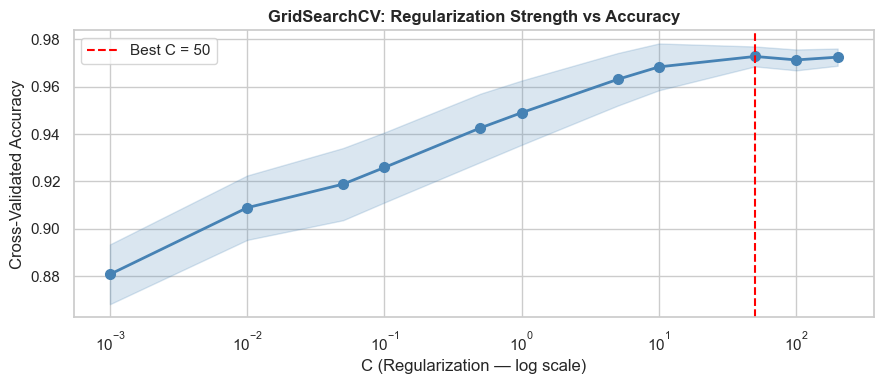

In [74]:
# Plotting C vs CV accuracy
cv_results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(9, 4))
plt.semilogx(cv_results['param_C'].astype(float), cv_results['mean_test_score'],
             'o-', color='steelblue', linewidth=2, markersize=7)
plt.fill_between(cv_results['param_C'].astype(float),
                 cv_results['mean_test_score'] - cv_results['std_test_score'],
                 cv_results['mean_test_score'] + cv_results['std_test_score'],
                 alpha=0.2, color='steelblue')
plt.axvline(best_C, color='red', linestyle='--', linewidth=1.5,
            label=f'Best C = {best_C}')
plt.xlabel('C (Regularization — log scale)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('GridSearchCV: Regularization Strength vs Accuracy', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [75]:
# solver='lbfgs' (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is an
# efficient quasi-Newton optimizer. It approximates the inverse Hessian
# using only gradient information from recent iterations, making it
# memory-efficient and well-suited for small-medium datasets like ours.

In [76]:
model = LogisticRegression(
    C=best_C,
    max_iter=5000,
    solver='lbfgs',
    random_state=42
)
model.fit(X_train_scaled, y_train)
 
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of Approved
 
test_acc = (y_pred == y_test).mean()
test_auc = roc_auc_score(y_test, y_proba)
 
print(f" Model trained with C = {best_C}")
print(f"\n Test Set Results")
print(f"Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"ROC-AUC  : {test_auc:.4f}")
print(f"\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

 Model trained with C = 50

 Test Set Results
Accuracy : 0.9824  (98.24%)
ROC-AUC  : 0.9934

 Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      0.98      0.98       323
    Approved       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



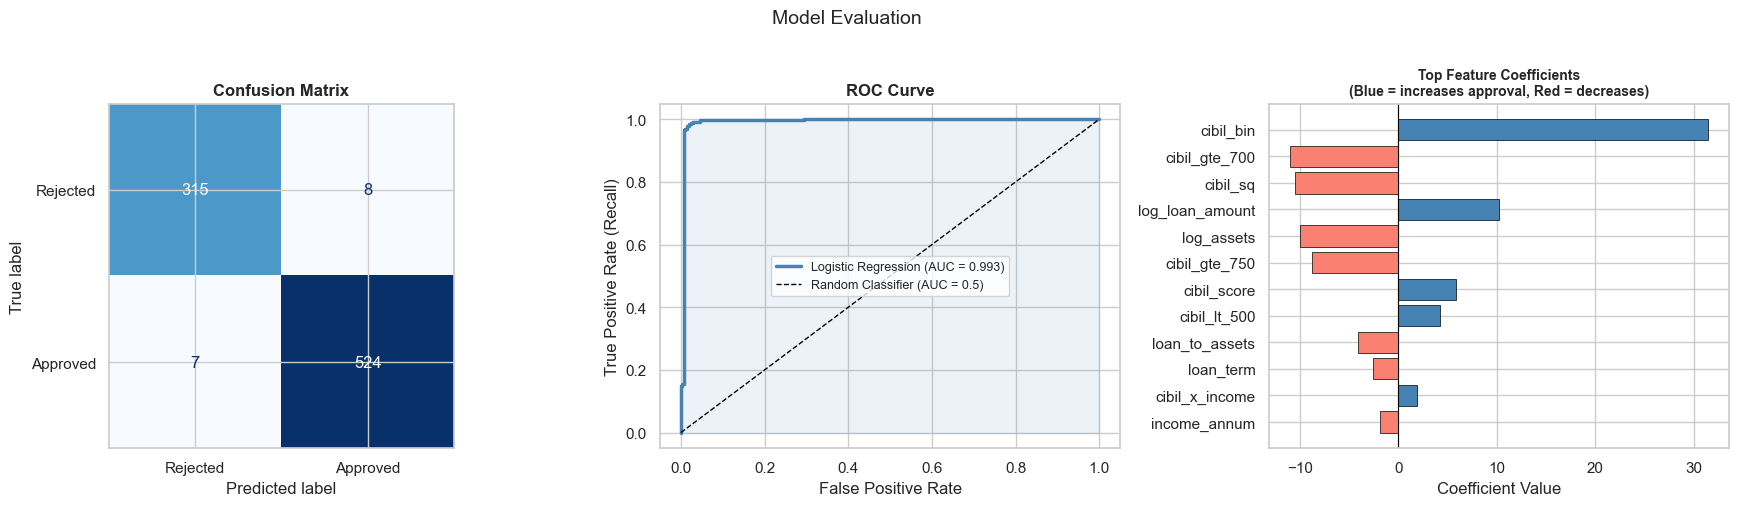

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#CM Display - Confu Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Rejected', 'Approved'],
    colorbar=False,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

#AUC-ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2.5,
             label=f'Logistic Regression (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

#Feature Imp
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Coefficient': model.coef_[0],
    'AbsCoef'   : np.abs(model.coef_[0])
}).sort_values('AbsCoef', ascending=True).tail(12)  # top 12
 
colors = ['steelblue' if c > 0 else 'salmon' for c in feat_imp['Coefficient']]
axes[2].barh(feat_imp['Feature'], feat_imp['Coefficient'], color=colors, edgecolor='black', linewidth=0.5)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Top Feature Coefficients\n(Blue = increases approval, Red = decreases)',
                   fontsize=10, fontweight='bold')
axes[2].set_xlabel('Coefficient Value')
 
plt.suptitle('Model Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [80]:
# AUC = 0.993 means the model ranks a randomly chosen approved applicant
# above a randomly chosen rejected one 99.3% of the time.
# Perfect classifier = AUC 1.0; random = 0.5.
# AUC is threshold-independent, unlike accuracy — it evaluates the model
# across all possible classification thresholds.

In [82]:
# Cross Validation and Accuracy Check
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=best_C, max_iter=5000, random_state=42))
])
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
cv_auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
 
print("=== 5-Fold Stratified Cross-Validation ===")
print(f"\nAccuracy per fold : {cv_acc_scores.round(4)}")
print(f"Mean Accuracy     : {cv_acc_scores.mean():.4f} ± {cv_acc_scores.std():.4f}")
print(f"\nROC-AUC per fold  : {cv_auc_scores.round(4)}")
print(f"Mean ROC-AUC      : {cv_auc_scores.mean():.4f} ± {cv_auc_scores.std():.4f}")
 
# Compare train vs test accuracy (overfitting check)
train_acc = model.score(X_train_scaled, y_train)
print(f"\nTrain Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Gap            : {abs(train_acc - test_acc):.4f}  ", end='')
if abs(train_acc - test_acc) < 0.02:
    print(" Minimal gap — no significant overfitting")
else:
    print("⚠ Notable gap — consider stronger regularization")

=== 5-Fold Stratified Cross-Validation ===

Accuracy per fold : [0.9742 0.9742 0.9731 0.9649 0.9707]
Mean Accuracy     : 0.9714 ± 0.0035

ROC-AUC per fold  : [0.9948 0.9924 0.9935 0.9945 0.9956]
Mean ROC-AUC      : 0.9942 ± 0.0011

Train Accuracy : 0.9725
Test Accuracy  : 0.9824
Gap            : 0.0100   Minimal gap — no significant overfitting


In [83]:
# We use StratifiedKFold (not simple KFold) because the dataset has class imbalance
# (62/38 split). StratifiedKFold ensures each fold preserves this ratio,
# giving more reliable estimates than random splits.

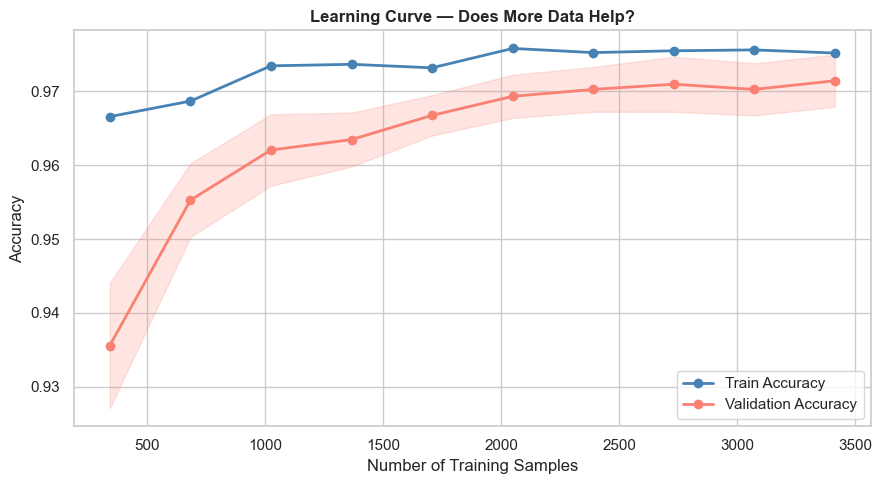


Validation accuracy at each data size:
  n= 341  →  val_acc=0.9356
  n= 683  →  val_acc=0.9553
  n=1024  →  val_acc=0.9621
  n=1366  →  val_acc=0.9635
  n=1707  →  val_acc=0.9667
  n=2049  →  val_acc=0.9693
  n=2390  →  val_acc=0.9702
  n=2732  →  val_acc=0.9710
  n=3073  →  val_acc=0.9703
  n=3415  →  val_acc=0.9714


In [84]:
# Synthetic Data Generation required? - By Learning Curve we'll know:
sizes, train_sc, val_sc = learning_curve(
    pipe, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)
 
plt.figure(figsize=(9, 5))
plt.plot(sizes, train_sc.mean(axis=1), 'o-', label='Train Accuracy',
         color='steelblue', linewidth=2)
plt.plot(sizes, val_sc.mean(axis=1),   'o-', label='Validation Accuracy',
         color='salmon', linewidth=2)
plt.fill_between(sizes, val_sc.mean(1) - val_sc.std(1),
                         val_sc.mean(1) + val_sc.std(1),
                 alpha=0.2, color='salmon')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Does More Data Help?', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
 
print("\nValidation accuracy at each data size:")
for s, v in zip(sizes, val_sc.mean(axis=1)):
    print(f"  n={int(s):4d}  →  val_acc={v:.4f}")

In [86]:
# If val accuracy is flat / plateau'd as n increases, more data won't help.
# The bottleneck is model expressiveness, not data quantity.

In [88]:
with open('scaler.pkl', 'wb') as f:
    pk.dump(scaler, f)
print("scaler.pkl saved")
 
with open('model.pkl', 'wb') as f:
    pk.dump(model, f)
print("model.pkl saved")
 
# Sanity check — reload and predict
loaded_scaler = pk.load(open('scaler.pkl', 'rb'))
loaded_model  = pk.load(open('model.pkl', 'rb'))
 
sample       = X_test.iloc[:5]
sample_scaled = loaded_scaler.transform(sample)
preds        = loaded_model.predict(sample_scaled)
labels       = ['Approved' if p == 1 else 'Rejected' for p in preds]
actual       = ['Approved' if a == 1 else 'Rejected' for a in y_test.iloc[:5].values]
 
print("\n Reload Sanity Check (5 samples)")
for i, (pred, act) in enumerate(zip(labels, actual)):
    match = 'Yes' if pred == act else 'No'
    print(f"  Sample {i+1}: Predicted={pred:8s}  Actual={act:8s}  {match}")

scaler.pkl saved
model.pkl saved

 Reload Sanity Check (5 samples)
  Sample 1: Predicted=Approved  Actual=Rejected  No
  Sample 2: Predicted=Rejected  Actual=Rejected  Yes
  Sample 3: Predicted=Rejected  Actual=Rejected  Yes
  Sample 4: Predicted=Approved  Actual=Approved  Yes
  Sample 5: Predicted=Approved  Actual=Approved  Yes


In [90]:
#Saving scaler and model to SEPARATE files.

In [91]:

app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import pickle as pk
 
st.set_page_config(page_title="LoanGenie", layout="centered")
st.header("🏦 LoanGenie - Loan Approval Predictor")
st.write("Fill in the details below to check if your loan is likely to be approved.")
 
try:
    scaler = pk.load(open("scaler.pkl", "rb"))
    model  = pk.load(open("model.pkl",  "rb"))
except Exception as e:
    st.error(f"Error loading model or scaler: {e}")
    st.stop()
 
# ── Inputs ────────────────────────────────────────────────────────────────────
col1, col2 = st.columns(2)
with col1:
    no_of_dep  = st.slider("Number of Dependents", 0, 5, 2)
    grad       = st.selectbox("Education Level", ["Graduate", "Not Graduate"])
    employment = st.selectbox("Self Employed?", ["No", "Yes"])
    income     = st.slider("Annual Income (INR)", 200000, 9900000, 5000000, step=100000)
 
with col2:
    loan_amt   = st.slider("Loan Amount Required (INR)", 300000, 39500000, 15000000, step=100000)
    loan_dur   = st.slider("Loan Duration (Years)", 2, 20, 10)
    cibil      = st.slider("CIBIL Score", 300, 900, 650)
    assets     = st.slider("Total Assets Value (INR)", 0, 58000000, 10000000, step=100000)
 
# ── Encode inputs (must match training encoding exactly) ───────────────────
grad_enc = 1 if grad == "Graduate" else 0      # Graduate=1, Not Graduate=0
emp_enc  = 1 if employment == "Yes" else 0     # Yes=1, No=0
 
# ── Feature Engineering (must mirror Cell 8 exactly) ──────────────────────
def build_feature_vector(no_of_dep, grad_enc, emp_enc,
                          income, loan_amt, loan_dur, cibil, assets):
    X = {
        # Base features
        "no_of_dependents": no_of_dep,
        "education"        : grad_enc,
        "self_employed"    : emp_enc,
        "income_annum"     : income,
        "loan_amount"      : loan_amt,
        "loan_term"        : loan_dur,
        "cibil_score"      : cibil,
        "assets"           : assets,
        # Engineered features
        "cibil_bin"        : float(np.searchsorted([499,549,599,649,699,724,749,800], cibil)),
        "cibil_gte_700"    : int(cibil >= 700),
        "cibil_gte_750"    : int(cibil >= 750),
        "cibil_lt_500"     : int(cibil <  500),
        "cibil_sq"         : cibil ** 2,
        "loan_to_income"   : loan_amt  / (income + 1),
        "loan_to_assets"   : loan_amt  / (assets + 1),
        "income_per_dep"   : income    / (no_of_dep + 1),
        "cibil_x_income"   : cibil     * income,
        "log_income_annum" : np.log1p(income),
        "log_loan_amount"  : np.log1p(loan_amt),
        "log_assets"       : np.log1p(assets),
    }
    return pd.DataFrame([X])
 

if st.button("🔍 Predict Loan Approval"):
    try:
        input_df     = build_feature_vector(no_of_dep, grad_enc, emp_enc,
                                             income, loan_amt, loan_dur, cibil, assets)
        input_scaled = scaler.transform(input_df)
        prediction   = model.predict(input_scaled)[0]
        probability  = model.predict_proba(input_scaled)[0][1]
 
        st.markdown("---")
        if prediction == 1:
            st.success(f"✅ Loan Approved  (Confidence: {probability*100:.1f}%)")
        else:
            st.error(f"❌ Loan Rejected  (Approval probability: {probability*100:.1f}%)")
 
        st.markdown(f"**CIBIL Score:** {cibil} | "
                    f"**Loan-to-Income Ratio:** {loan_amt/income:.2f}x | "
                    f"**Loan-to-Assets Ratio:** {loan_amt/max(assets,1):.2f}x")
    except Exception as e:
        st.error(f"Prediction failed: {e}")
'''
 
with open('loan_approval_app.py', 'w') as f:
    f.write(app_code)
 
print(" loan_approval_app.py written successfully")
print("\nTo run the app:")
print("  streamlit run loan_approval_app.py")
 

✅ loan_approval_app.py written successfully

To run the app:
  streamlit run loan_approval_app.py
